In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from aux import format_plot
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from time import time

plt.rcParams['font.family'] = 'Helvetica'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def calc_alpha_func(tau_alpha):
	alpha_func_n_steps = int(10 * tau_alpha / dt)
	t_alpha = np.arange(0, alpha_func_n_steps) * dt
	return np.e * t_alpha / tau_alpha * np.exp(-t_alpha/tau_alpha)

def poisson_arrivals_to_inputs(arrivals, tau_alpha):
	alpha_func = calc_alpha_func(tau_alpha)
	input_current = np.zeros(arrivals.shape)

	for i in range(arrivals.shape[1]):
		input_current[:, i] = np.convolve(alpha_func, arrivals[:, i], mode='full')[:arrivals.shape[0]]
	return input_current

In [30]:
BATCH_SIZE = 10
T = 0.3
T_INPUT = 0.27
INPUT_RATE_PER_CELL = 1000
dt = 1e-4 # Timesteps
INPUT_BLOCK_DURATION = 10e-3
input_block_timesteps = int(INPUT_BLOCK_DURATION / dt)
input_start = int(20e-3/dt)
input_end = input_start + int(T_INPUT/dt)
max_input_len = input_end - input_start
decoder_lag = int(5e-3/dt)
decoding_len = int(T / dt - decoder_lag - input_start)
n_e_side = 10

def gen_input_1(index):
    input_rate_for_trial = 2 * INPUT_RATE_PER_CELL * (0.25 + 0.75 * index / (BATCH_SIZE - 1))
    
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
    n_input_blocks = max_input_len // input_block_timesteps
    inputs = np.random.choice([-1, 0, 1], size=n_input_blocks).astype(int)
    
    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=input_rate_for_trial * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=input_rate_for_trial * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block
    filtered_input_to_sum_per_neuron = poisson_arrivals_to_inputs(input_spks, 3e-3)
    filtered_input_to_sum = filtered_input_to_sum_per_neuron[:, n_e_side:2 * n_e_side].sum(axis=1) - filtered_input_to_sum_per_neuron[:, :n_e_side].sum(axis=1)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
            running_input_sums[j] += filtered_input_to_sum[j]
            
    return filtered_input_to_sum_per_neuron, running_input_sums / max_input_len

(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)
(2799, 20)


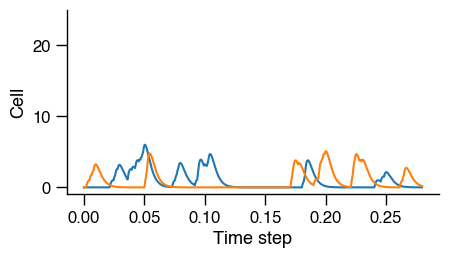

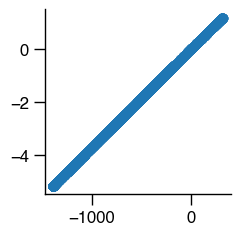

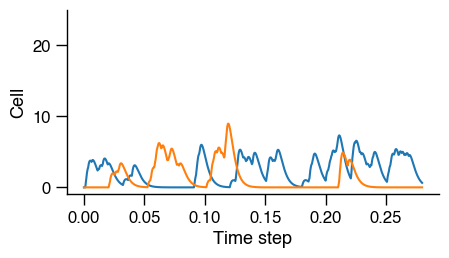

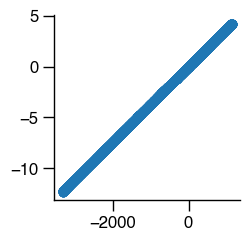

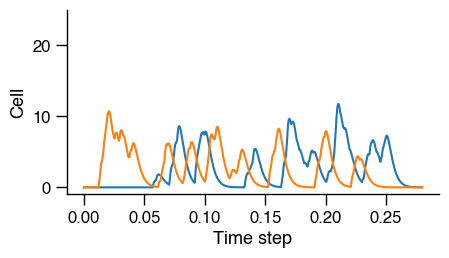

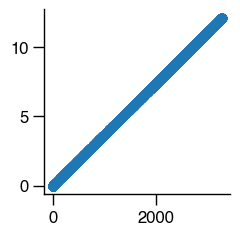

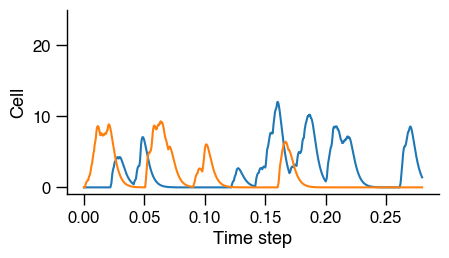

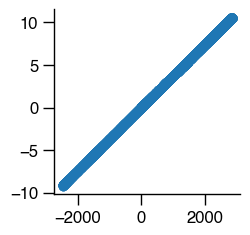

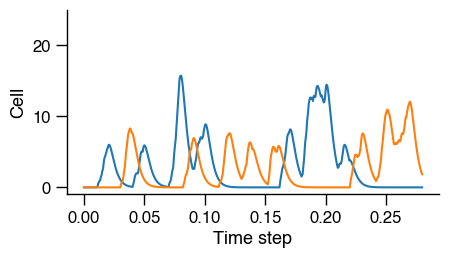

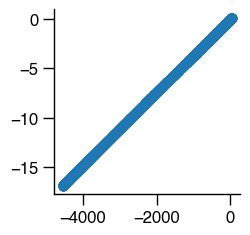

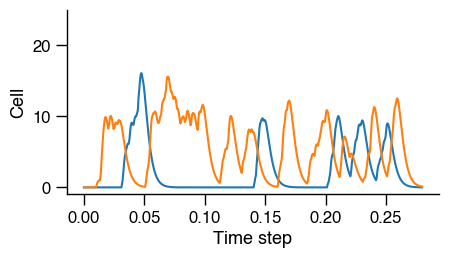

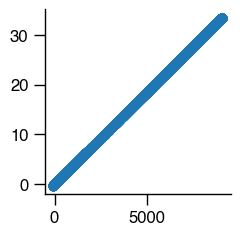

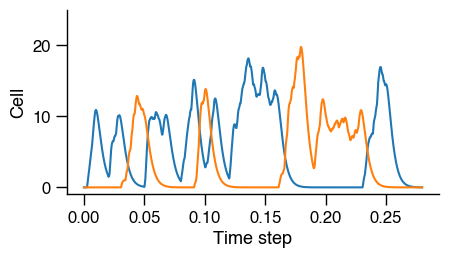

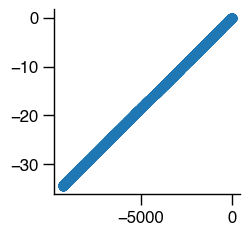

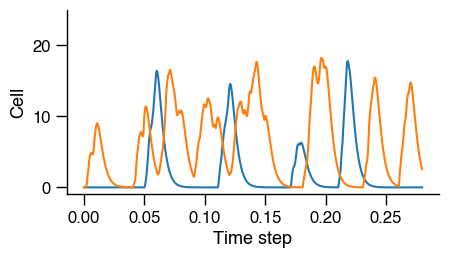

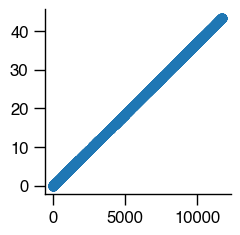

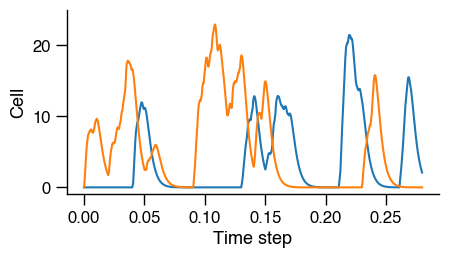

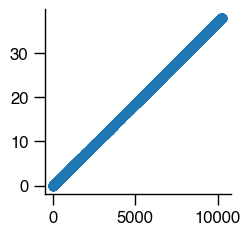

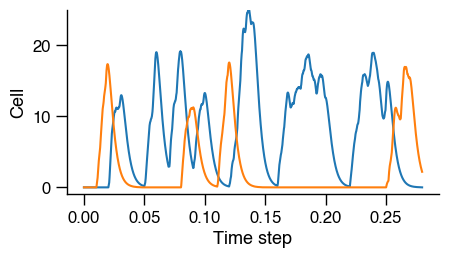

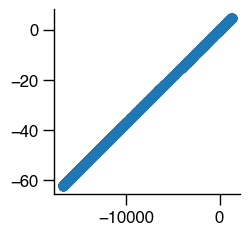

In [31]:
for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, targets = gen_input_1(i)
    
    print(inputs.shape)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])

    axes.set_ylim(-1, 25)

    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)
    
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))
    
    axes.scatter(-np.cumsum(inputs, axis=0)[:, 0] + np.cumsum(inputs, axis=0)[:, 10], targets)
    
    format_plot(axes)

In [32]:
def gen_input_2(index):
    input_len = int((index + 1) / (BATCH_SIZE + 1) * max_input_len)
    
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
		
    n_input_blocks = input_len // input_block_timesteps
    inputs = np.zeros((n_input_blocks), dtype=int)
    n_inputs = np.random.randint(0, n_input_blocks + 1)
    if n_inputs > 0:
        inputs[:n_inputs] = np.random.choice([-1, 1], size=n_inputs)
    np.random.shuffle(inputs)

    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block

    filtered_input_to_sum_per_neuron = poisson_arrivals_to_inputs(input_spks, 3e-3)
    filtered_input_to_sum = filtered_input_to_sum_per_neuron[:, n_e_side:2 * n_e_side].sum(axis=1) - filtered_input_to_sum_per_neuron[:, :n_e_side].sum(axis=1)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
            running_input_sums[j] += filtered_input_to_sum[j]
            
    return filtered_input_to_sum_per_neuron, running_input_sums / max_input_len

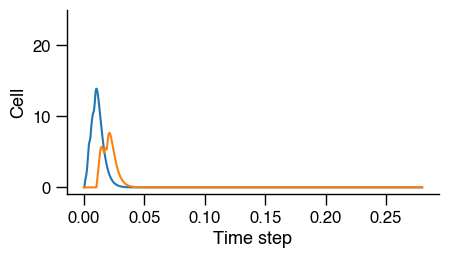

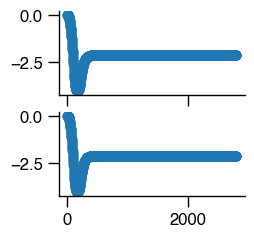

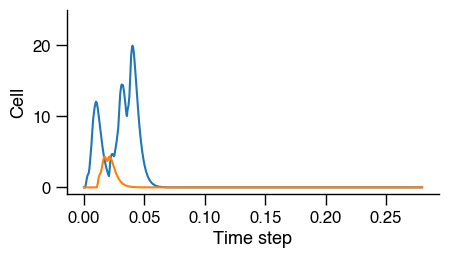

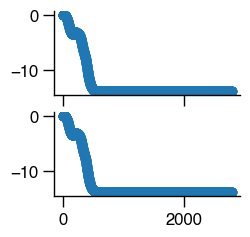

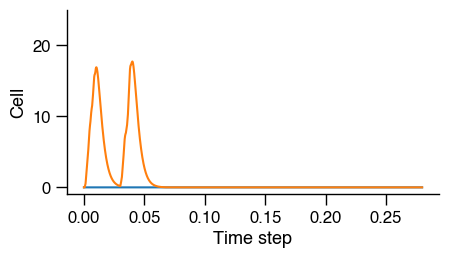

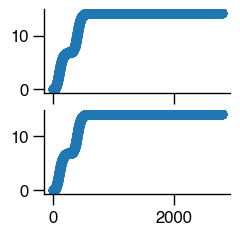

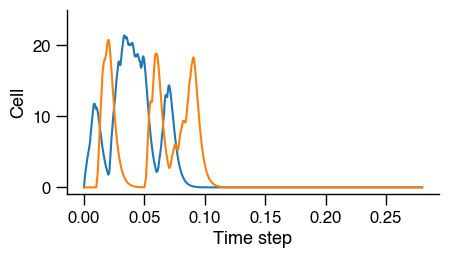

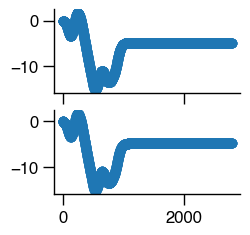

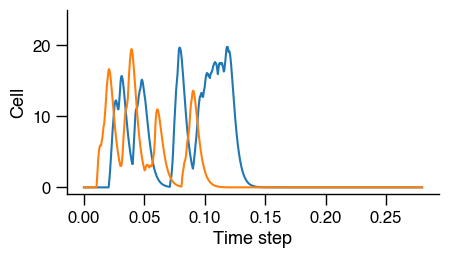

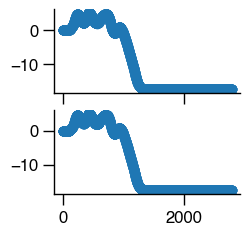

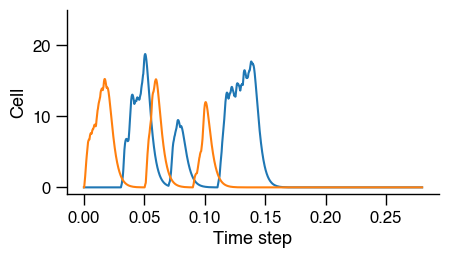

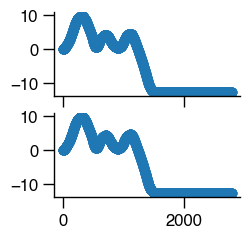

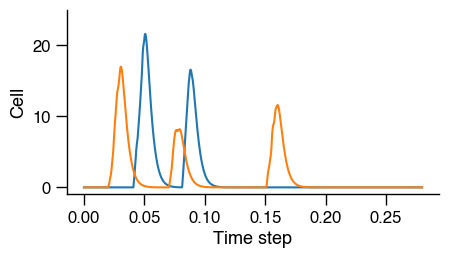

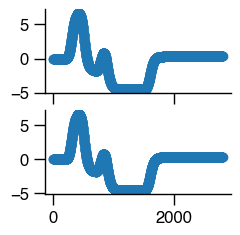

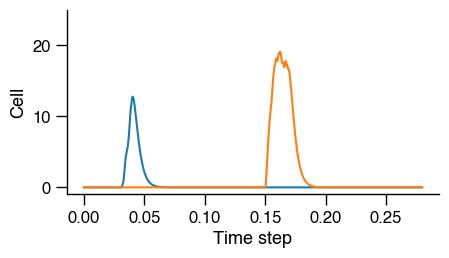

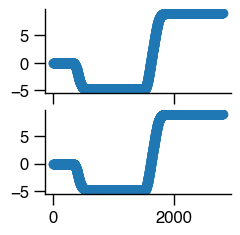

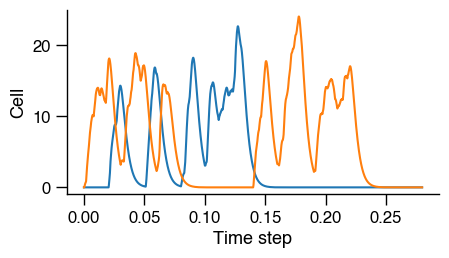

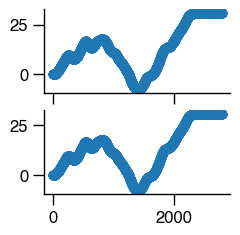

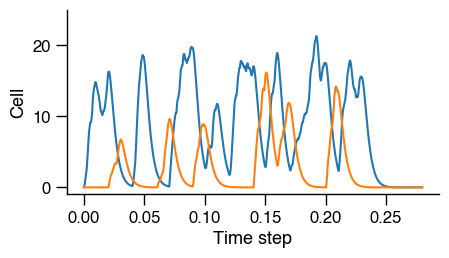

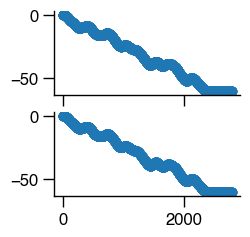

In [36]:
INPUT_BLOCK_DURATION = 10e-3
input_block_timesteps = int(INPUT_BLOCK_DURATION / dt)

for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, targets = gen_input_2(i)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])
    axes.set_ylim(-1, 25)
    
    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)
    
    scale = 0.6
    fig, axes = plt.subplots(2, 1, figsize=(4 * scale, 4 * scale))
    
    axes[0].scatter(np.arange(len(targets)), targets)
    
    axes[1].scatter(np.arange(len(targets)), targets)
    
    format_plot(axes)

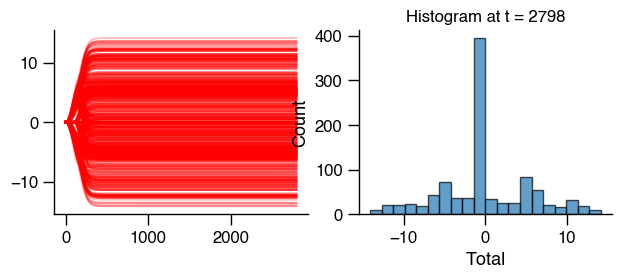

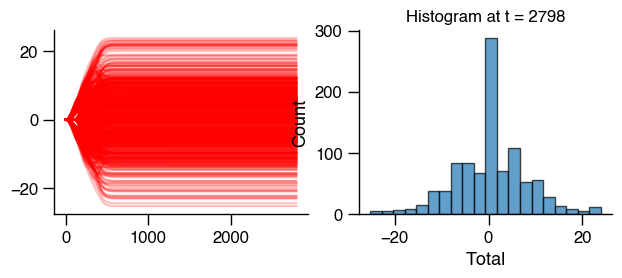

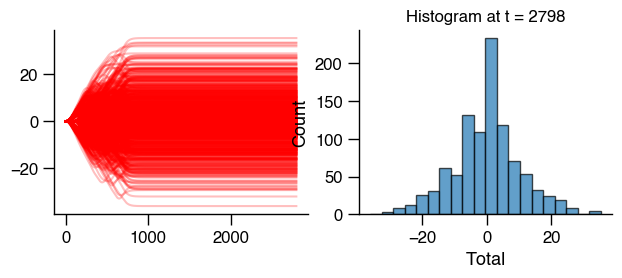

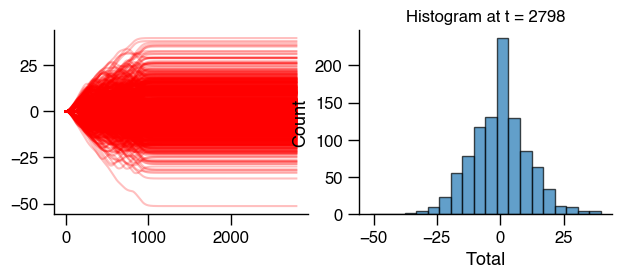

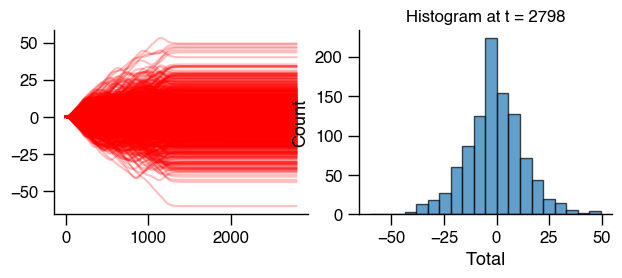

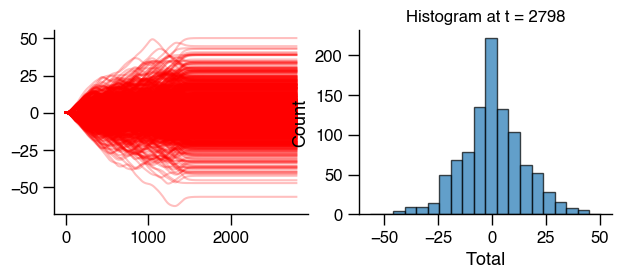

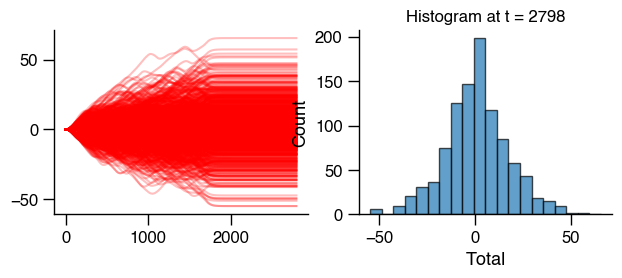

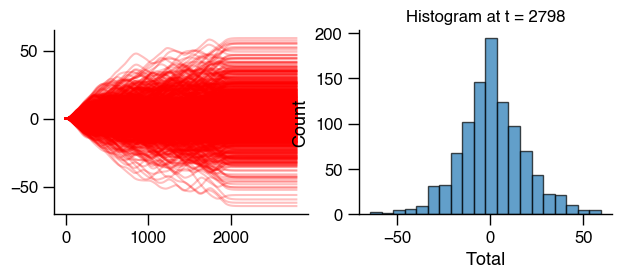

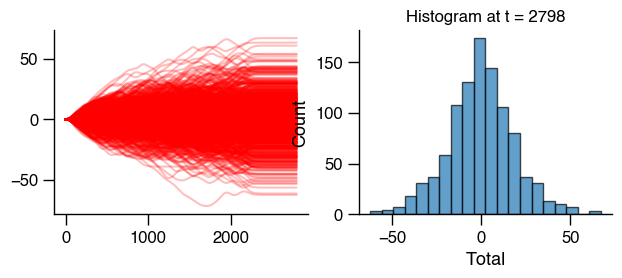

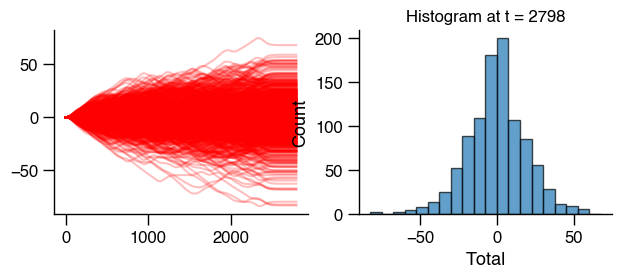

In [60]:
for index in range(10):
    fig, axes = plt.subplots(1, 2, figsize=(12 * scale, 4 * scale))
    
    # Left panel: traces
    trace_ax = axes[0]
    # Right panel: histogram
    hist_ax = axes[1]
    
    all_totals_at_t = []
    t_idx = 2798  # <-- choose the timestep you want
    
    for i in range(1000):
        inputs, totals = gen_input_2(index)
        totals /= (0.3 / dt)
    
        # store the value at time t_idx
        if t_idx < len(totals):
            all_totals_at_t.append(totals[t_idx])
    
        trace_ax.plot(np.arange(len(totals)), totals, alpha=0.25, color='red')
    
    format_plot(trace_ax)
    
    # Histogram of values at timestep t_idx
    hist_ax.hist(all_totals_at_t, bins=20, edgecolor='black', alpha=0.7)
    hist_ax.set_title(f"Histogram at t = {t_idx}")
    hist_ax.set_xlabel("Total")
    hist_ax.set_ylabel("Count")
    format_plot(hist_ax)

In [41]:
def gen_input_3(index):
    input_len = max_input_len
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
    n_input_blocks = input_len // input_block_timesteps

    p_active = 0.25 + 0.75 * index / BATCH_SIZE
    inputs = np.random.choice([0, -1, 1], size=n_input_blocks, p=[1-p_active, p_active/2, p_active/2])

    for i_input_block, input_flag in enumerate(inputs):
        k = i_input_block * input_block_timesteps
        if input_flag == -1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif input_flag == 1:
            input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block

    filtered_input_to_sum_per_neuron = poisson_arrivals_to_inputs(input_spks, 3e-3)
    print(filtered_input_to_sum_per_neuron.shape)
    filtered_input_to_sum = filtered_input_to_sum_per_neuron[:, n_e_side:2 * n_e_side].sum(axis=1) - filtered_input_to_sum_per_neuron[:, :n_e_side].sum(axis=1)
    print(filtered_input_to_sum.shape)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
            running_input_sums[j] += filtered_input_to_sum[j]
            
    return filtered_input_to_sum_per_neuron, running_input_sums / max_input_len

(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)
(2799, 20)
(2799,)


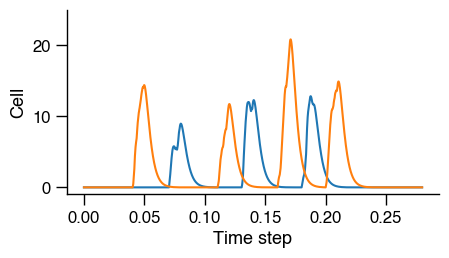

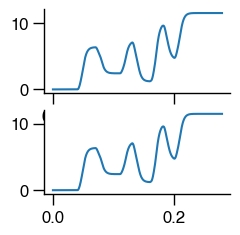

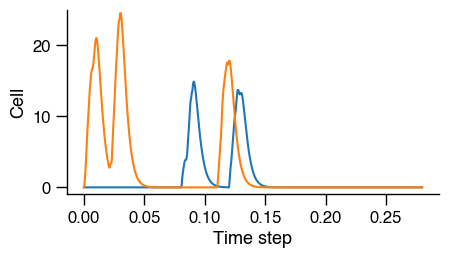

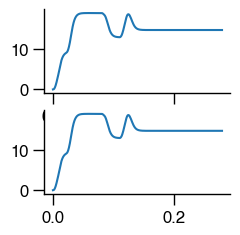

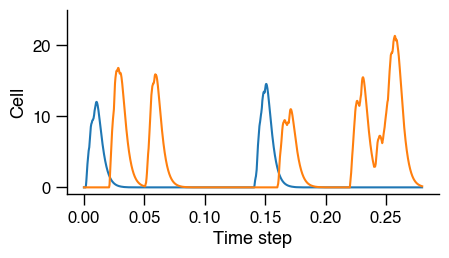

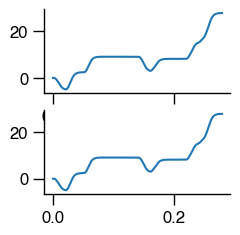

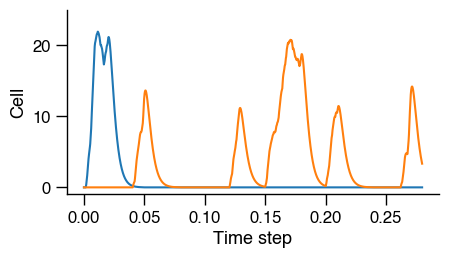

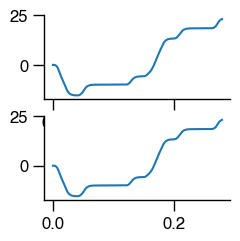

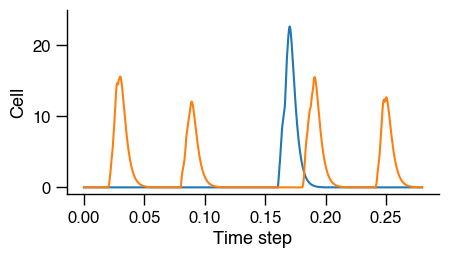

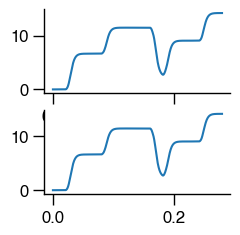

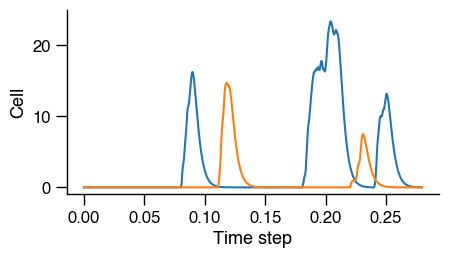

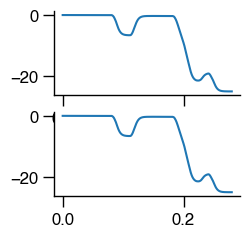

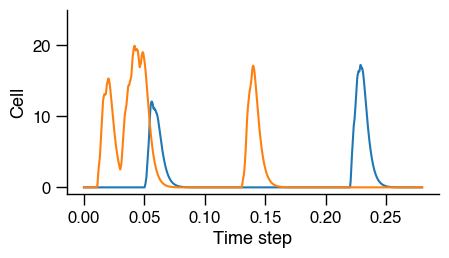

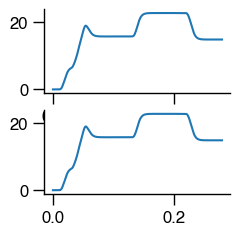

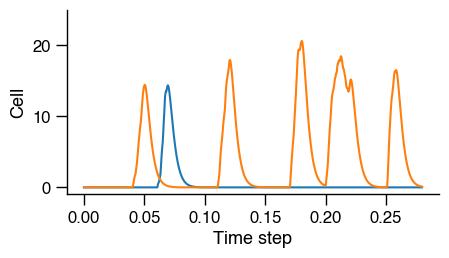

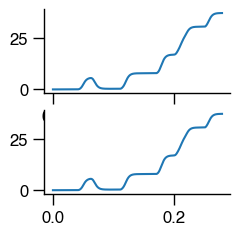

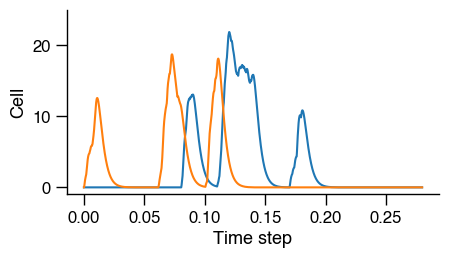

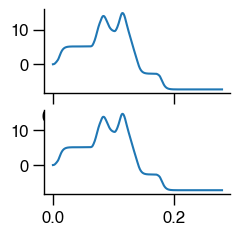

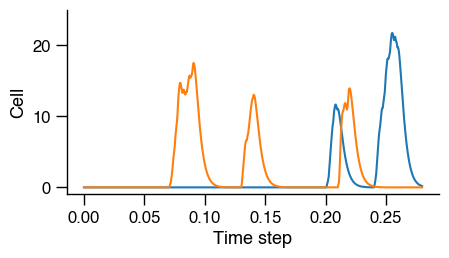

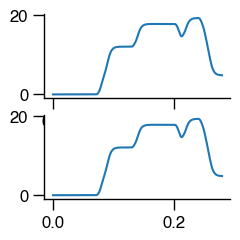

In [45]:
for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, targets = gen_input_3(0)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])
    axes.set_ylim(-1, 25)
    
    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)
    
    scale = 0.6
    fig, axes = plt.subplots(2, 1, figsize=(4 * scale, 4 * scale))
    
    axes[0].plot(np.arange(len(targets)) * dt, targets)
    
    axes[1].plot(np.arange(len(targets)) * dt, targets)
    
    format_plot(axes)

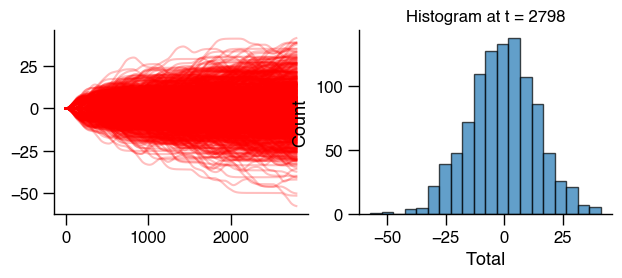

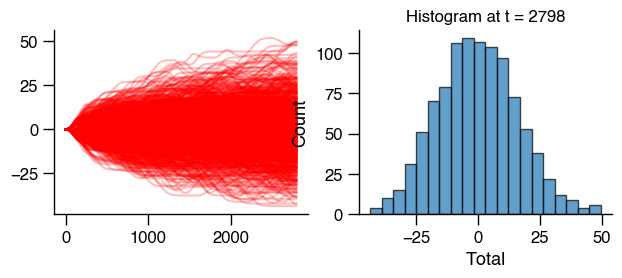

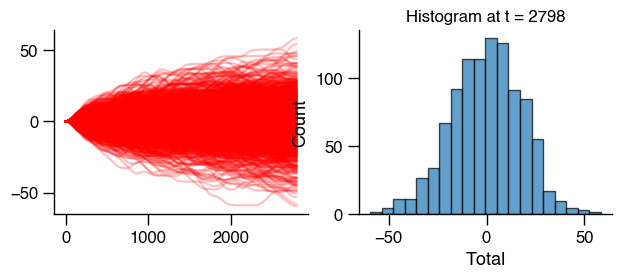

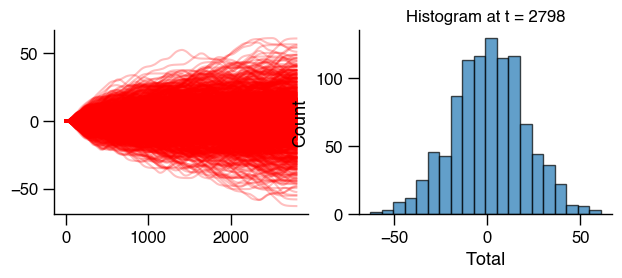

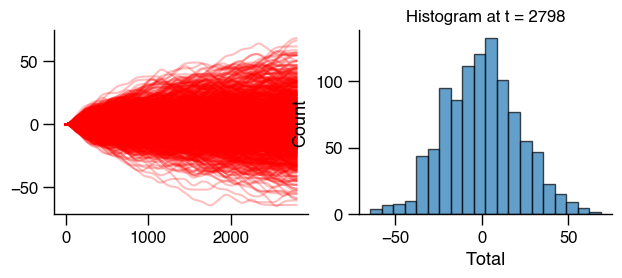

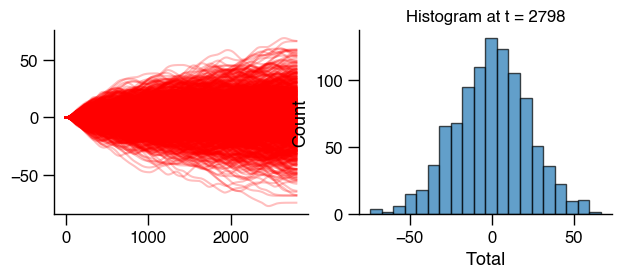

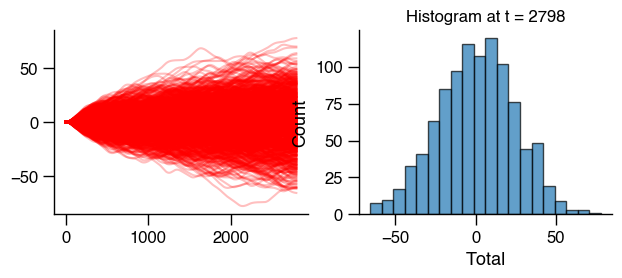

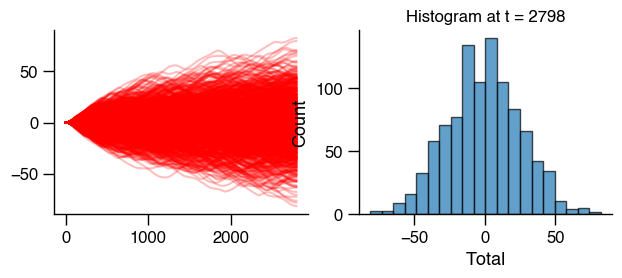

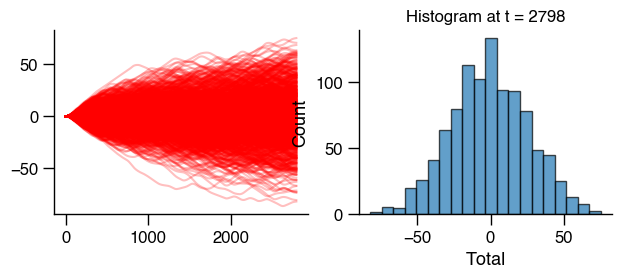

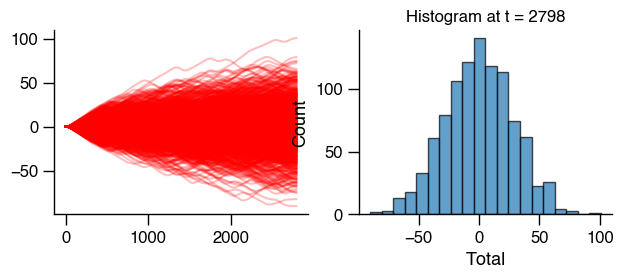

In [61]:
for index in range(10):
    fig, axes = plt.subplots(1, 2, figsize=(12 * scale, 4 * scale))
    
    # Left panel: traces
    trace_ax = axes[0]
    # Right panel: histogram
    hist_ax = axes[1]
    
    all_totals_at_t = []
    t_idx = 2798  # <-- choose the timestep you want
    
    for i in range(1000):
        inputs, totals = gen_input_3(index)
        totals /= (0.3 / dt)
    
        # store the value at time t_idx
        if t_idx < len(totals):
            all_totals_at_t.append(totals[t_idx])
    
        trace_ax.plot(np.arange(len(totals)), totals, alpha=0.25, color='red')
    
    format_plot(trace_ax)
    
    # Histogram of values at timestep t_idx
    hist_ax.hist(all_totals_at_t, bins=20, edgecolor='black', alpha=0.7)
    hist_ax.set_title(f"Histogram at t = {t_idx}")
    hist_ax.set_xlabel("Total")
    hist_ax.set_ylabel("Count")
    format_plot(hist_ax)

In [43]:
def gen_input_4(index):
    input_len = max_input_len
    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))

    input_spks = np.zeros((decoding_len + decoder_lag, 2 * n_e_side))
    inputs = np.zeros((decoding_len + decoder_lag,)).astype(int)
    inputs[0] = np.random.choice([-1, 0, 1])

    for k in range(input_len):
        if k % input_block_timesteps == 0:
            inputs[k] = np.random.choice([-1, 0, 1])
            if inputs[k] == -1:
                input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)), n_e_side, axis=1)
                input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
            elif inputs[k] == 1:
                input_block = np.repeat(np.random.poisson(lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, 1)),n_e_side, axis=1)
                input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = input_block
            else:
                inputs[k] = inputs[k-1]
    
    filtered_input_to_sum_per_neuron = poisson_arrivals_to_inputs(input_spks, 3e-3)
    filtered_input_to_sum = filtered_input_to_sum_per_neuron[:, n_e_side:2 * n_e_side].sum(axis=1) - filtered_input_to_sum_per_neuron[:, :n_e_side].sum(axis=1)
    running_input_sums = np.zeros_like(filtered_input_to_sum)
    for j in range(len(running_input_sums)):
        if j > 0:
            running_input_sums[j] += running_input_sums[j-1]
            running_input_sums[j] += filtered_input_to_sum[j]
            
    return filtered_input_to_sum_per_neuron, running_input_sums / max_input_len

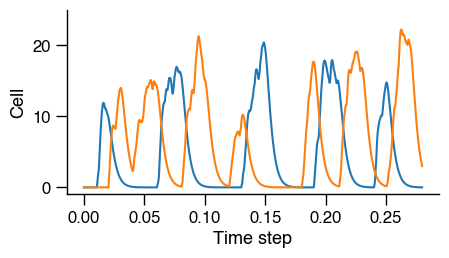

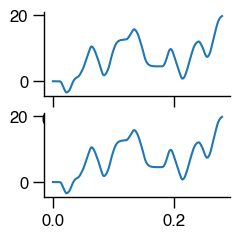

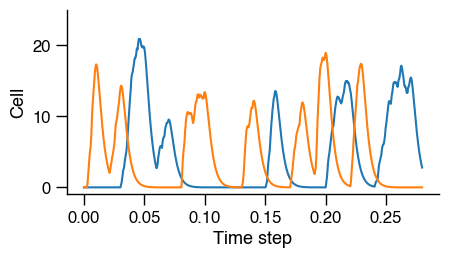

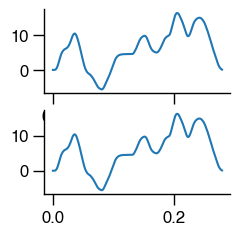

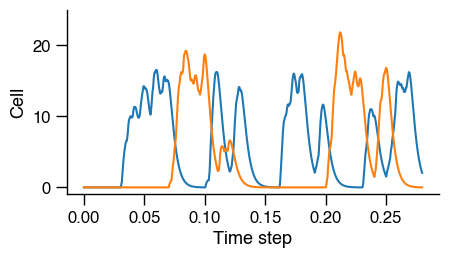

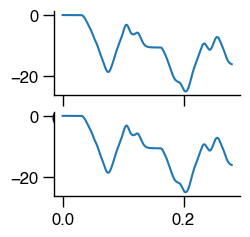

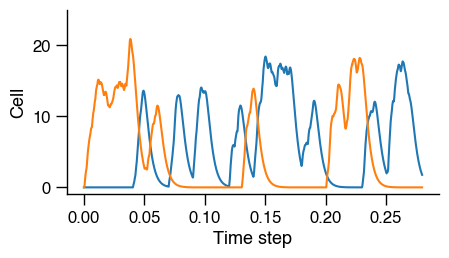

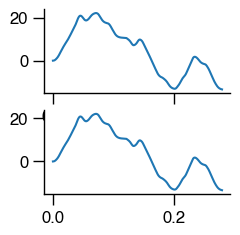

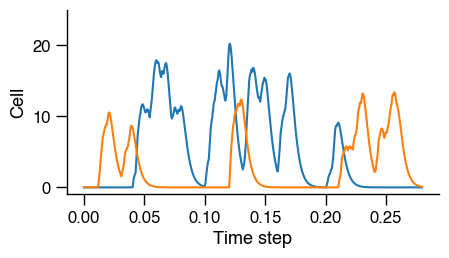

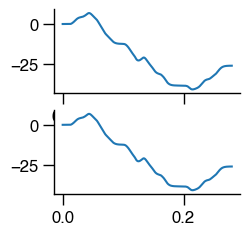

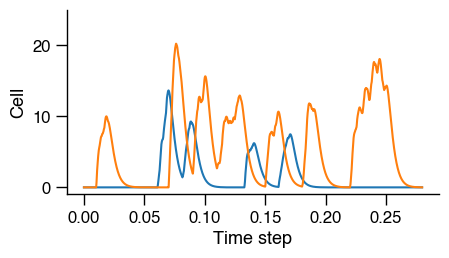

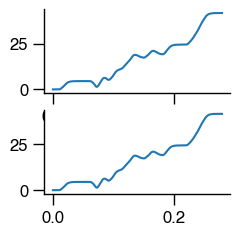

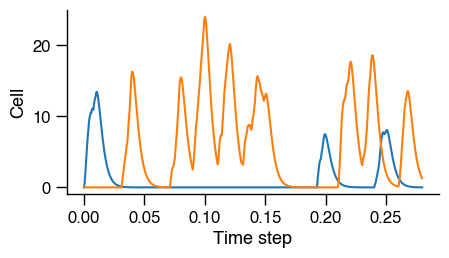

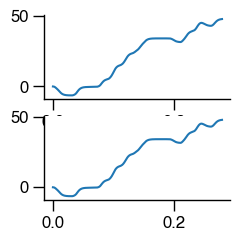

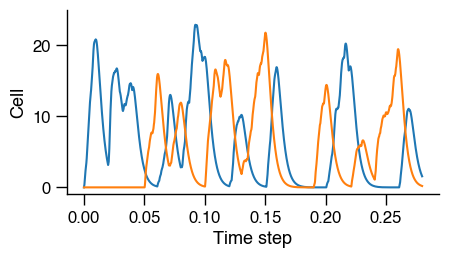

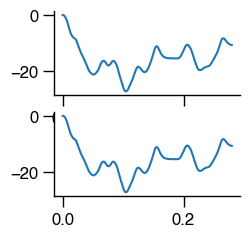

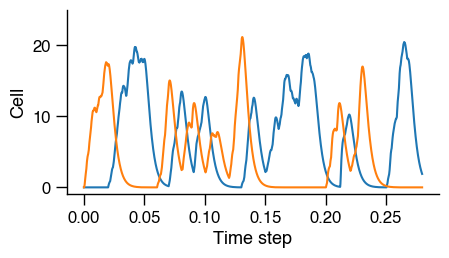

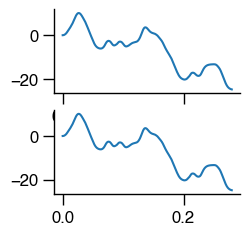

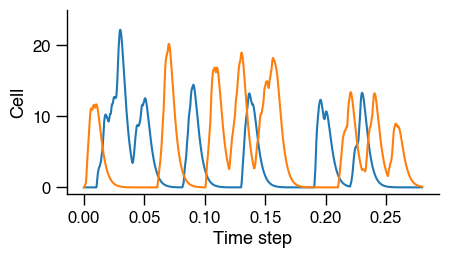

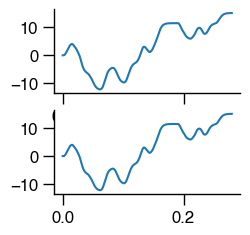

In [44]:
for i in range(10):
    scale = 0.6
    fig, axes = plt.subplots(1, 1, figsize=(8 * scale, 4 * scale))
    
    inputs, targets = gen_input_4(i)
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 0])
    axes.plot(np.arange(inputs.shape[0]) * dt, inputs[:, 10])
    axes.set_ylim(-1, 25)
    
    axes.set_xlabel('Time step')
    axes.set_ylabel('Cell')

    format_plot(axes)
    
    scale = 0.6
    fig, axes = plt.subplots(2, 1, figsize=(4 * scale, 4 * scale))
    
    axes[0].plot(np.arange(len(targets)) * dt, targets)
    
    axes[1].plot(np.arange(len(targets)) * dt, targets)
    
    format_plot(axes)